<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day13_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 13 Lab: imbalanced data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import validation_curve
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.metrics import classification_report

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE


In [2]:
file_link = 'https://drive.google.com/uc?export=download&id=1_EHeUYiwejkcKICmLfm49XdK8Y9VBSzt'

# uhoh, semicolons
df = pd.read_csv(file_link, sep=';')

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [3]:
ord_map = {
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}
df['education'] = df['education'].map(ord_map)
df = df[df['education'] != 'unknown']


In [4]:
ord_map = {
    'no': 0,
    'yes': 1
}
df['default'] = df['default'].map(ord_map)
df['y'] = df['y'].map(ord_map)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,1.0,0,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,0
1,33,services,married,2.0,0,4789,yes,yes,cellular,11,may,220,1,339,4,failure,0
2,35,management,single,3.0,0,1350,yes,no,cellular,16,apr,185,1,330,1,failure,0
3,30,management,married,3.0,0,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,2.0,0,0,yes,no,unknown,5,may,226,1,-1,0,unknown,0


Add a couple more columns

In [5]:
# poutcome
df['poutcome'].value_counts()

,count
poutcome,
unknown,3705
failure,490
other,197
success,129


In [6]:
df = pd.get_dummies(df, columns=['poutcome'], dtype=int)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               4521 non-null   int64  
 1   job               4521 non-null   object 
 2   marital           4521 non-null   object 
 3   education         4334 non-null   float64
 4   default           4521 non-null   int64  
 5   balance           4521 non-null   int64  
 6   housing           4521 non-null   object 
 7   loan              4521 non-null   object 
 8   contact           4521 non-null   object 
 9   day               4521 non-null   int64  
 10  month             4521 non-null   object 
 11  duration          4521 non-null   int64  
 12  campaign          4521 non-null   int64  
 13  pdays             4521 non-null   int64  
 14  previous          4521 non-null   int64  
 15  y                 4521 non-null   int64  
 16  poutcome_failure  4521 non-null   int64  


In [8]:
# make sure there are no NaNs, or SMOTE won't be happy
df = df.dropna(subset=['education'])


y = df['y']
X = df[['age', 'education', 'default', 'balance', 'previous',
        'pdays', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']]


## Split into train/test sets
Make sure to stratify when data is imbalanced

In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.5, random_state=13, stratify=y)


## Train an XGBClassifier

In [10]:
model = XGBClassifier()
model.fit(Xtrain, ytrain)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

1. Predict the test data to get a baseline accuracy that we’ll try to improve by finding better hyperparameters.
2. Show a confusion matrix.
3. Show the classification report that includes precision and recall.


0.8758652514997692


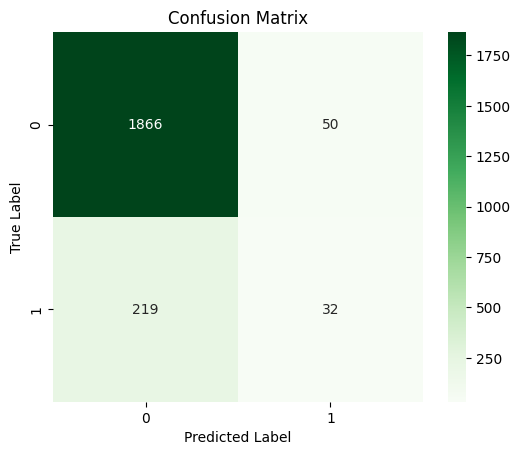

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1916
           1       0.39      0.13      0.19       251

    accuracy                           0.88      2167
   macro avg       0.64      0.55      0.56      2167
weighted avg       0.84      0.88      0.85      2167



In [11]:
ypred = model.predict(Xtest)

accuracy = accuracy_score(ytest, ypred)
print(accuracy)

classes = ytrain.unique()
cm = confusion_matrix(ytest, ypred, labels=classes)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                    cmap="Greens",
                    xticklabels=classes,
                    yticklabels=classes)

plt.xlabel('Predicted Label');
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(ytest, ypred))


## Sampling

In [12]:
print('undersampling')
undersample = RandomUnderSampler(random_state=0)
Xtrain_resampled, ytrain_resampled = undersample.fit_resample(Xtrain, ytrain)

print(Xtrain.shape)
print(Xtrain_resampled.shape)
model = XGBClassifier()
model.fit(Xtrain_resampled, ytrain_resampled)
ypred = model.predict(Xtest)
print(classification_report(ytest, ypred))


undersampling
(2167, 10)
(502, 10)
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      1916
           1       0.16      0.61      0.25       251

    accuracy                           0.58      2167
   macro avg       0.54      0.59      0.48      2167
weighted avg       0.83      0.58      0.66      2167



In [13]:
print('oversampling')
oversample = RandomOverSampler(random_state=0)
Xtrain_resampled, ytrain_resampled = oversample.fit_resample(Xtrain, ytrain)

print(Xtrain.shape)
print(Xtrain_resampled.shape)

model = XGBClassifier()
model.fit(Xtrain_resampled, ytrain_resampled)
ypred = model.predict(Xtest)
print(classification_report(ytest, ypred))


oversampling
(2167, 10)
(3832, 10)
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1916
           1       0.19      0.21      0.20       251

    accuracy                           0.80      2167
   macro avg       0.54      0.54      0.54      2167
weighted avg       0.81      0.80      0.81      2167



In [14]:
print('SMOTE')
oversample = SMOTE(random_state=0)
Xtrain_resampled, ytrain_resampled = oversample.fit_resample(Xtrain, ytrain)

model = XGBClassifier()
model.fit(Xtrain_resampled, ytrain_resampled)
ypred = model.predict(Xtest)
print(classification_report(ytest, ypred))


SMOTE
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1916
           1       0.30      0.22      0.25       251

    accuracy                           0.85      2167
   macro avg       0.60      0.58      0.59      2167
weighted avg       0.83      0.85      0.84      2167



In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4334 entries, 0 to 4520
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               4334 non-null   int64  
 1   education         4334 non-null   float64
 2   default           4334 non-null   int64  
 3   balance           4334 non-null   int64  
 4   previous          4334 non-null   int64  
 5   pdays             4334 non-null   int64  
 6   poutcome_failure  4334 non-null   int64  
 7   poutcome_other    4334 non-null   int64  
 8   poutcome_success  4334 non-null   int64  
 9   poutcome_unknown  4334 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 372.5 KB


## Now pick whichever seems best

In [16]:
undersample = RandomUnderSampler(random_state=0)
Xtrain_resampled, ytrain_resampled = undersample.fit_resample(Xtrain, ytrain)

# oversample = SMOTE(random_state=0)
# Xtrain_resampled, ytrain_resampled = oversample.fit_resample(Xtrain, ytrain)


## For your selected type of sampling, perform a grid search to find the best model you can. For scoring, choose f1_weighted, to get a good balance of precision and recall.

In [17]:
# params = {
#     'n_estimators': np.arange(1, 311, 25),
#     'max_depth': np.arange(1, 26, 5),
#     'learning_rate': np.arange(0.01, 1, 0.3)
# }

# grid = GridSearchCV(XGBClassifier(), param_grid=params, cv=3, verbose=1, scoring='f1_weighted')
# grid.fit(Xtrain_resampled, ytrain_resampled)

# grid.best_params_


In [18]:
# hyperparams learned with undersampling
model = XGBClassifier(learning_rate=0.91, max_depth=1, n_estimators=251)

# hyperparams learned with SMOTE
# model = XGBClassifier(learning_rate=0.61, max_depth=21, n_estimators=76)

model.fit(Xtrain_resampled, ytrain_resampled)
ypred = model.predict(Xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1916
           1       0.19      0.54      0.28       251

    accuracy                           0.68      2167
   macro avg       0.55      0.62      0.54      2167
weighted avg       0.84      0.68      0.73      2167



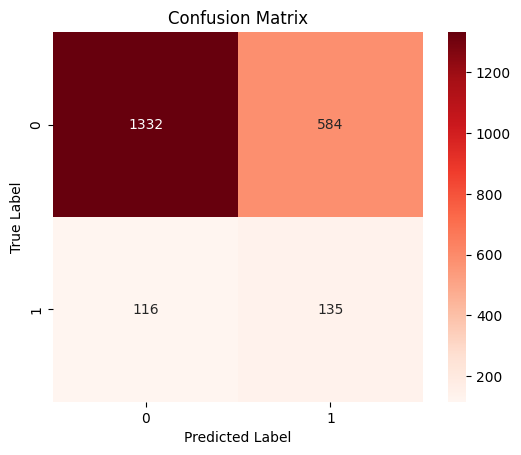

In [19]:
classes = ytrain.unique()
cm = confusion_matrix(ytest, ypred, labels=classes)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                    cmap="Reds",
                    xticklabels=classes,
                    yticklabels=classes)

plt.xlabel('Predicted Label');
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
